# PseudoAlexNetTiny training and fine-tuning

## Additional functions

In [2]:
import os
from typing import Optional

os.makedirs("/kaggle/working/", exist_ok=True)
def save_checkpoint(model, optimizer, epoch, loss, path="/kaggle/working/", file_name=None):
    """
    Saves a 'Neutral' checkpoint by manually migrating tensors to CPU.
    Bypasses torch_xla version issues.
    """
    cpu_state_dict = {k: v.to('cpu') for k, v in model.state_dict().items()}
    
    cpu_opt_dict = {}
    for k, v in optimizer.state_dict().items():
        if k == 'state':
            cpu_opt_dict[k] = {idx: {p_k: p_v.to('cpu') if torch.is_tensor(p_v) else p_v 
                                     for p_k, p_v in p_v.items()} 
                               for idx, p_v in v.items()}
        else:
            cpu_opt_dict[k] = v

    state = {
        'epoch': epoch,
        'state_dict': cpu_state_dict,
        'optimizer': cpu_opt_dict,
        'loss': loss,
    }
    
    full_path = f"{path}{file_name if file_name else f'after_{epoch}_checkpoint'}.pth"
    
    torch.save(state, full_path)
    print(f"✅ Neutral Checkpoint saved to {full_path}")

def load_checkpoint(model, optimizer, path, device):
    """
    Loads checkpoint into CPU first to strip headers, then moves to current device.
    """
    if os.path.exists(path):
        checkpoint = torch.load(path, map_location=device)
        
        load_status = model.load_state_dict(checkpoint['state_dict'], strict=False)
        
        if optimizer is not None:
            optimizer.load_state_dict(checkpoint['optimizer'])
            for state in optimizer.state.values():
                for k, v in state.items():
                    if torch.is_tensor(v):
                        state[k] = v.to(device)
        
        epoch = checkpoint['epoch']
        loss = checkpoint['loss']
        
        print(f"🔄 Checkpoint loaded. Status: {load_status}")
        print(f"Resuming from Epoch {epoch} | Loss: {loss:.4f}")
        return epoch, loss
    else:
        print(f"⚠️ Path not found: {path}")
        return 0, float('inf')

In [3]:
import torch.nn.functional as F
import time
import torch
from typing import List, Tuple, Optional

def train_and_eval_epoch(epoch, model, train_loader, val_loader, 
                         optimizer, loss_fn, device, log_interval, checkpoint_dir, stage_name: str = "nat_images") -> Tuple[float, Optional[float]]:
    epoch_start_time = time.time()

    model.train()
    local_train_loss_sum = 0.0
    local_train_steps = 0
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = loss_fn(output, target)
        loss.backward()

        optimizer.step()
    
        local_train_loss_sum += loss.item()
        local_train_steps += 1

        if batch_idx % log_interval == 0:
            print(f'Train Epoch: {epoch} '
                  f'[{batch_idx * len(data)}/{len(train_loader)*128} '
                  f'({100. * batch_idx / len(train_loader):.0f}%)]\tLoss: {loss.item():.6f}')
        only_once = True
    
    
    if local_train_steps > 0:
        avg_train_loss = local_train_loss_sum / local_train_steps
    else:
        avg_train_loss = float('inf')

    print(f'--- Epoch {epoch} Training Metrics ---')
    print(f'Average Train Loss: {avg_train_loss:.6f}')

 
    model.eval()
    local_val_loss_sum = 0.0
    local_val_steps = 0

    with torch.no_grad():
        for data, target in val_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            loss = loss_fn(output, target)
            
            local_val_loss_sum += loss.item()
            local_val_steps += 1

    
    if local_val_steps > 0:
        avg_val_loss = local_val_loss_sum / local_val_steps
    else:
        avg_val_loss = float('inf')
    
    print(f'\n--- Epoch {epoch} Evaluation ---')
    print(f'Validation set: Average Loss: {avg_val_loss:.6f}\n')

    if epoch % 10 == 0:
        file_name = f"after_{epoch}_{stage_name}"
        save_checkpoint(model, optimizer, epoch, avg_train_loss, path=checkpoint_dir, file_name=file_name)

    epoch_finish_time = time.time()

    print(f"Total time of epoch {epoch} is {epoch_finish_time - epoch_start_time:.2f}s\n")
    return avg_train_loss, avg_val_loss

In [49]:
import matplotlib.pyplot as plt

def plot_learning_curves(train_losses, val_losses, title="Model Loss Progression"):
    """
    Plots the training and testing loss curves.
    
    Args:
        train_losses (list or numpy array): A list of training loss values per epoch.
        test_losses (list or numpy array): A list of test/validation loss values per epoch.
        title (str): The title of the plot.
    """
    # Create the figure
    plt.figure(figsize=(10, 6))
    
    # Plot the lines
    # We use a solid line for training and a dashed line for testing for clear contrast
    plt.plot(train_losses, label='Training Loss', color='blue', linewidth=2, linestyle='-')
    plt.plot(val_losses, label='Validation Loss', color='orange', linewidth=2, linestyle='--')
    
    # Add labels and title
    plt.title(title, fontsize=16, fontweight='bold')
    plt.xlabel('Epoch', fontsize=14)
    plt.ylabel('Loss', fontsize=14)
    
    # Add a grid for easier reading of values
    plt.grid(True, linestyle=':', alpha=0.7)
    
    # Add the legend
    plt.legend(loc='upper right', fontsize=12)
    
    # Adjust layout to prevent cutting off labels
    plt.tight_layout()
    
    # Display the plot
    plt.show()

## Preparation of the data Caltech101(natural images)

### 1. Loading the dataset and creating train/val split.

In [7]:
import torch
from torchvision import datasets
from torchvision.transforms import v2

transforms = v2.Compose([
    v2.Resize((300,200)),
    v2.RGB(),
    v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
])

transforms_augmented_list = [
    v2.Compose([
        v2.RandomHorizontalFlip(p=0.5),
        v2.RandomRotation(10),
        
    ]),
    v2.Compose([
        v2.RandomHorizontalFlip(p=0.5),
        v2.ColorJitter(),
    ])
]
def load_dataset(data_augmented=True, transforms_original=None, transforms_augmented_list=None):
    original_dataset = datasets.Caltech101(root='./data', download=True, transform=transforms_original)
    if data_augmented:
    
        augmented_datasets = [
            datasets.Caltech101(root='./data', download=True, transform=
                                v2.Compose([t,transforms_original]))
            for t in transforms_augmented_list
        ]
        return torch.utils.data.ConcatDataset([original_dataset] + augmented_datasets)
    else:
        return original_datasets

In [8]:
from torch.utils.data import Dataset, Subset
from sklearn.model_selection import train_test_split
import numpy as np

def stratified_three_way_split(
    dataset: Dataset, 
    train_ratio: float, 
    test_ratio: float, 
    val_ratio: float, 
    random_state: int = 42
):
    """
    Extracts a stratified train, validation, and test split from a PyTorch Dataset,
    ensuring exact class proportions are maintained across all three.
    """
    # Sanity check to ensure the mathematical ratios make sense
    assert np.isclose(train_ratio + val_ratio + test_ratio, 1.0), "Ratios must sum to 1.0!"

    # 1. Safely extract targets regardless of dataset structure
    if hasattr(dataset, 'targets'):
        targets = dataset.targets
    elif hasattr(dataset, 'labels'):
        targets = dataset.labels
    elif hasattr(dataset, 'y'):
        targets = dataset.y
    else:
        targets = [dataset[i][1] for i in range(len(dataset))]

    # 2. Format targets and cast to a NumPy array to allow easy advanced indexing later
    if torch.is_tensor(targets):
        targets = targets.cpu().numpy()
    elif isinstance(targets, list) and torch.is_tensor(targets[0]):
        targets = np.array([t.item() for t in targets])
    else:
        targets = np.array(targets)

    # 3. Generate base dataset indices
    indices = np.arange(len(dataset))

    # --- FIRST SPLIT: Separate Train from the temporary pool (Val + test) ---
    train_indices, temp_indices = train_test_split(
        indices,
        train_size=train_ratio,
        stratify=targets,
        random_state=random_state
    )

    # --- SECOND SPLIT: Separate the temporary pool into test and val ---
    # Calculate the relative size of the val split within the remaining data pool
    # e.g., if val=0.15 and test=0.15, relative_test_size is 0.15 / 0.30 = 0.50 (50% of the remainder)
    relative_test_size = test_ratio / (test_ratio + val_ratio)
    
    val_indices, test_indices = train_test_split(
        temp_indices,
        test_size=relative_test_size,
        stratify=targets[temp_indices],  # Filter targets for the remaining indices
        random_state=random_state
    )

    # 4. Return the resulting three PyTorch Subsets
    return Subset(dataset, train_indices), Subset(dataset, val_indices), Subset(dataset, test_indices)

In [9]:
nat_images = load_dataset(data_augmented=True, transforms_original=transforms, transforms_augmented_list=transforms_augmented_list)

100%|██████████| 137M/137M [00:03<00:00, 39.7MB/s] 


In [10]:
nat_images_train, nat_images_val, nat_images_test = stratified_three_way_split(dataset=nat_images, train_ratio=0.7, 
                                                                             val_ratio=0.15, test_ratio=0.15, random_state=317)

### 2. Validating the stratification of the train/val/test split

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def visualize_dataset_distribution(train_ds, val_ds, test_ds, class_names=None):
    """
    Visualizes and compares the class distribution among train, validation, and test sets.
    """
    def get_labels(dataset):
        # Optimized for ImageFolder; falls back to iteration for custom datasets
        if hasattr(dataset, 'targets'):
            return dataset.targets
        elif hasattr(dataset, 'labels'):
            return dataset.labels
        elif hasattr(dataset, 'y'):
            return dataset.y
        else:
            return [label for _, label in dataset]

    # 1. Extract labels for all three splits
    train_labels = get_labels(train_ds)
    val_labels = get_labels(val_ds)
    test_labels = get_labels(test_ds)

    # 2. Create and merge DataFrames for Seaborn
    df_train = pd.DataFrame({'Label': train_labels, 'Split': 'Train'})
    df_val = pd.DataFrame({'Label': val_labels, 'Split': 'Validation'})
    df_test = pd.DataFrame({'Label': test_labels, 'Split': 'test'})
    df_all = pd.concat([df_train, df_val, df_test])

    # 3. Plotting
    plt.figure(figsize=(15, 8))
    # The 'viridis' palette scales smoothly to accommodate the third bar cluster
    ax = sns.countplot(data=df_all, x='Label', hue='Split', palette='viridis')
    
    if class_names:
        ax.set_xticklabels(class_names, rotation=90)
    
    plt.title('Class Distribution: Train vs Validation vs test Split', fontsize=16)
    plt.xlabel('Class Index', fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(title='Dataset Split')
    plt.tight_layout()
    plt.show()

    # 4. Calculate and print precise dataset proportions
    total_samples = len(train_labels) + len(val_labels) + len(test_labels)
    
    print(f"Total Training Samples:   {len(train_labels)} ({len(train_labels) / total_samples * 100:.1f}%)")
    print(f"Total Validation Samples: {len(val_labels)} ({len(val_labels) / total_samples * 100:.1f}%)")
    print(f"Total test Samples:       {len(test_labels)} ({len(test_labels) / total_samples * 100:.1f}%)")
    print(f"Total Combined Samples:   {total_samples}")

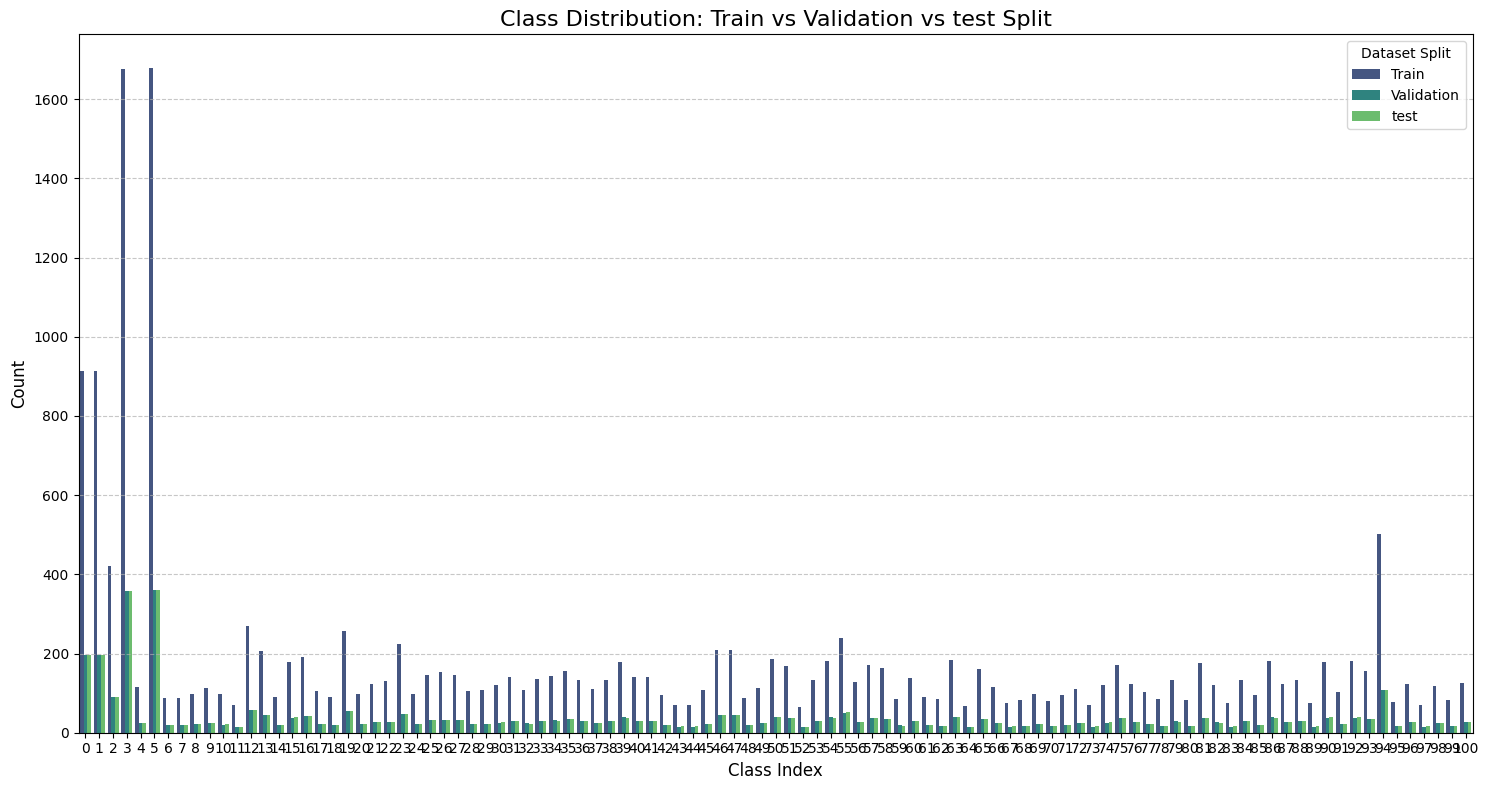

Total Training Samples:   18221 (70.0%)
Total Validation Samples: 3905 (15.0%)
Total test Samples:       3905 (15.0%)
Total Combined Samples:   26031


In [12]:
visualize_dataset_distribution(train_ds=nat_images_train, val_ds=nat_images_val, test_ds=nat_images_test)

### 3. Creating the DataLoader for the datasets

In [13]:
batch_size = 128
nat_train_loader = torch.utils.data.DataLoader(nat_images_train, batch_size=batch_size, shuffle=True, num_workers=3)
nat_val_loader = torch.utils.data.DataLoader(nat_images_val, batch_size=batch_size, shuffle=False, num_workers=3)
nat_test_loader = torch.utils.data.DataLoader(nat_images_test, batch_size=batch_size, shuffle=False, num_workers=3)

## Preparation of the model for Caltech101

In [4]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [56]:
import torch.nn.init as init

class ConvBN2d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0, negative_slope=0.01):
        super().__init__()

        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding)
        self.bn = nn.BatchNorm2d(out_channels)
        
        # Save the slope so it is accessible in the forward pass and init steps
        self.negative_slope = negative_slope 

        # Execute custom weight initialization
        self.reset_parameters()

    def reset_parameters(self):
        init.kaiming_uniform_(self.conv.weight, a=self.negative_slope, nonlinearity='leaky_relu')
        
        if self.conv.bias is not None:
            init.zeros_(self.conv.bias)
            
        init.ones_(self.bn.weight)
        init.zeros_(self.bn.bias)

    def forward(self, x):
        # Using the saved instance variable self.negative_slope
        return F.leaky_relu(self.bn(self.conv(x)), negative_slope=self.negative_slope)

In [61]:
import math 

class PseudoAlexNet(nn.Module):
    def __init__(self, p=0.5, negative_slope=0.01, tiny_factor: int = 1):
        super(PseudoAlexNet, self).__init__()
        # Input image dimension baseline: 3 x 300 x 200
        self.tiny_factor = tiny_factor
        # --- 1. THE VISION BACKBONE (All spatial layers go here) ---
        self.features = nn.Sequential(
            # Layer 1
            ConvBN2d(in_channels=3, out_channels=int((1.0/self.tiny_factor)*12), kernel_size=5, stride=2, padding=2, negative_slope=negative_slope),
            
            # Layer 2 + Pool
            ConvBN2d(in_channels=int((1.0/self.tiny_factor)*12), out_channels=int((1.0/self.tiny_factor)*16), kernel_size=3, stride=1, padding=1, negative_slope=negative_slope),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Layer 3
            ConvBN2d(in_channels=int((1.0/self.tiny_factor)*16), out_channels=int((1.0/self.tiny_factor)*24), kernel_size=3, stride=1, padding=1, negative_slope=negative_slope),
            
            # Layer 4 + Pool
            ConvBN2d(in_channels=int((1.0/self.tiny_factor)*24), out_channels=int((1.0/self.tiny_factor)*32), kernel_size=3, stride=1, padding=1, negative_slope=negative_slope),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # --- 2. THE CLASSIFICATION HEAD (All vector dense layers go here) ---
        self.classifier = nn.Sequential(
            nn.Dropout(p),
            nn.Linear(self.tiny_factor*32 * 37 * 25, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(negative_slope=negative_slope),
            nn.Dropout(p),
            nn.Linear(256, 101)
        )

        for layer in self.classifier:
            if isinstance(layer, nn.Linear):
                init.kaiming_uniform_(layer.weight, a=negative_slope, nonlinearity='leaky_relu')
                if layer.bias is not None:
                    fan_in, _ = init._calculate_fan_in_and_fan_out(layer.weight)
                    bound = 1 / math.sqrt(fan_in)
                    init.uniform_(layer.bias, -bound, bound)

    def forward(self, x):
        # 1. Extract structural features [Batch, 32, 37, 25]
        x = self.features(x)
        
        # 2. Flatten spatial dimensions into a single vector
        x = x.view(x.size(0), -1) 

        # 3. Pass through the classification brain
        x = self.classifier(x)
        
        return F.log_softmax(x, dim=1)

## Training the model on Caltech101

In [26]:
import torch.optim
MAX_NAT_EPOCHS = 40
CONFIDENCE_THRESHOLD = 1e-6*2
SEED = 317

model = PseudoAlexNet() # with dropout and with LeakyReLU
DEVICE = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
model = model.to(DEVICE)
    
loss_fn = nn.NLLLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-3) # adding L2 regularization

val_loss_list_nat = []
train_loss_list_nat = []

In [27]:
print("=== Training on the natural images ===")

prev_loss = 0.0
#initial freeze of all layers and unfreeze of the fully connected layers.
print(f"Starting training of the natural images in {MAX_NAT_EPOCHS} epochs.")
start_nat_time = time.time()
for epoch in range(1, MAX_NAT_EPOCHS + 1):
    print(f" Natural training epoch {epoch}/{MAX_NAT_EPOCHS}...")
    
    # Run your function
    train_loss, val_loss = train_and_eval_epoch(epoch=epoch, model=model, train_loader=nat_train_loader,
                                                       val_loader=nat_val_loader,optimizer=optimizer, loss_fn=loss_fn,
                                                       device=DEVICE,log_interval=3, checkpoint_dir="/kaggle/working/",
                                                       stage_name="nat_images")
    
    train_loss_list_nat.append(train_loss)
    val_loss_list_nat.append(val_loss)
    loss_diff = abs(prev_loss - val_loss)
    if loss_diff <= CONFIDENCE_THRESHOLD:
        print(f"\n>>> THRESHOLDS MET at Epoch {epoch} <<<")
        print(">>> Head is fully calibrated. Breaking natural images cycle.")
        save_checkpoint(model=model, optimizer=optimizer, epoch=epoch, loss=val_loss_list_nat[-1], 
                        path="/kaggle/working/", file_name="finished_nat_images") 
        break # Exit the warm-up loop early

    if epoch == MAX_NAT_EPOCHS:
        save_checkpoint(model=model, optimizer=optimizer, epoch=epoch, loss=val_loss_list_nat[-1],
                        path="/kaggle/working/", file_name="finished_nat_images_max_epochs")       
    prev_loss = val_loss

print(f"Finished natural images training in {time.time() - start_nat_time}")

=== Training on the natural images ===
Starting training of the natural images in 40 epochs.
 Natural training epoch 1/40...
Train Epoch: 1 [0/18304 (0%)]	Loss: 5.460930
Train Epoch: 1 [384/18304 (2%)]	Loss: 5.207653
Train Epoch: 1 [768/18304 (4%)]	Loss: 4.736654
Train Epoch: 1 [1152/18304 (6%)]	Loss: 4.157195
Train Epoch: 1 [1536/18304 (8%)]	Loss: 4.064809
Train Epoch: 1 [1920/18304 (10%)]	Loss: 3.936467
Train Epoch: 1 [2304/18304 (13%)]	Loss: 3.455122
Train Epoch: 1 [2688/18304 (15%)]	Loss: 3.775430
Train Epoch: 1 [3072/18304 (17%)]	Loss: 3.469919
Train Epoch: 1 [3456/18304 (19%)]	Loss: 3.491456
Train Epoch: 1 [3840/18304 (21%)]	Loss: 3.835253
Train Epoch: 1 [4224/18304 (23%)]	Loss: 3.368631
Train Epoch: 1 [4608/18304 (25%)]	Loss: 3.344499
Train Epoch: 1 [4992/18304 (27%)]	Loss: 2.988161
Train Epoch: 1 [5376/18304 (29%)]	Loss: 3.026779
Train Epoch: 1 [5760/18304 (31%)]	Loss: 3.465954
Train Epoch: 1 [6144/18304 (34%)]	Loss: 3.028672
Train Epoch: 1 [6528/18304 (36%)]	Loss: 3.027911
Tra

In [28]:
model.eval()
local_test_loss_sum = 0.0
local_test_steps = 0

# 1. Initialize counters for accuracy
correct_predictions = 0
total_samples = 0

device = DEVICE
with torch.no_grad():
    for data, target in nat_test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        loss = loss_fn(output, target)
        
        local_test_loss_sum += loss.item()
        local_test_steps += 1
    
        predicted_classes = output.argmax(dim=1, keepdim=True)
        
        correct_predictions += predicted_classes.eq(target.view_as(predicted_classes)).sum().item()
        
        total_samples += target.size(0)

if local_test_steps > 0:
    avg_test_loss = local_test_loss_sum / local_test_steps
    # 5. Calculate the final accuracy ratio
    accuracy = correct_predictions / total_samples
else:
    avg_test_loss = float('inf')
    accuracy = 0.0
    
print(f'=== Test set: Final Average Loss: {avg_test_loss:.6f} | Accuracy: {correct_predictions}/{total_samples} ({accuracy * 100:.2f}%) === \n')

=== Test set: Final Average Loss: 0.299941 | Accuracy: 3657/3905 (93.65%) === 



## Plotting training and validation test losses

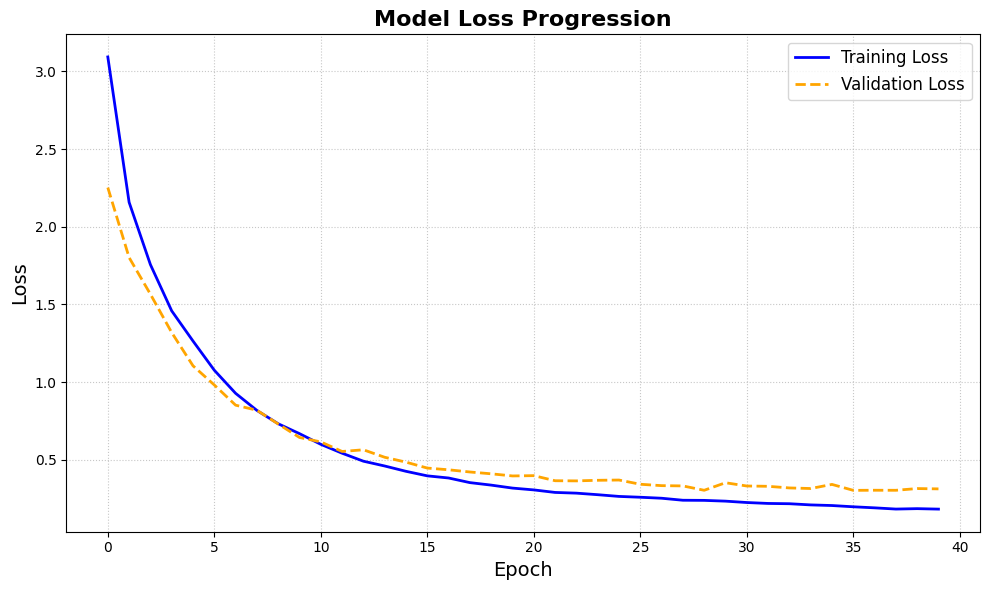

In [30]:
plot_learning_curves(train_losses=train_loss_list_nat,val_losses=val_loss_list_nat)

## Preparation of the data Enrico(screen images) - popular classes only

### 1. Custom dataset class for Enrico

In [7]:
import os
import pandas as pd
from PIL import Image
import torch
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split
from typing import Optional, Dict, Any, Callable, List, Union, Tuple

class CustomEnricoDataset(Dataset):
    def __init__(self, 
                 root: str,
                 screen_ids: List[str],
                 labels_dict: Dict[str, str],
                 class_to_idx: Dict[str, int],
                 transform: Optional[Callable] = None, 
                 transform_to_class: Optional[Dict[str, Union[Callable, List[Callable]]]] = None,
                 augment_for_each: Optional[List[Callable]] = None):
        """
        Internal constructor. Use CustomEnricoDataset.create_splits() to initialize 
        train and val datasets comfortably from a Kaggle path.
        """
        self.root = root
        self.img_dir = os.path.join(self.root, "screenshots/screenshots")
        self.transform = transform
        self.transform_to_class = transform_to_class or {}
        
        self.screen_ids = screen_ids
        self.labels_dict = labels_dict
        self.class_to_idx = class_to_idx

        self.samples = []
        for screen_id in self.screen_ids:
            label_str = self.labels_dict.get(screen_id)
            if label_str:
                self.samples.append((screen_id, None)) 

                for aug in augment_for_each:
                    self.samples.append((screen_id, aug))
                    
                if label_str in self.transform_to_class:
                    augs = self.transform_to_class[label_str]
                    augs = [augs] if not isinstance(augs, list) else augs
                    for aug in augs:
                        self.samples.append((screen_id, aug))

    @classmethod
    def create_splits(cls, 
                      root: str, 
                      val_size: float = 0.15, 
                      test_size: float = 0.15,
                      seed: int = 42,
                      transform: Optional[Callable] = None,
                      transform_to_class: Optional[Dict] = None,
                      augment_for_each: Optional[List] = None,
                      allowed_classes : Optional[List[str]] = None) -> Tuple['CustomEnricoDataset', 'CustomEnricoDataset', 'CustomEnricoDataset']:
        """
        Reads the Kaggle directory, performs a stratified train/val/test split,
        and returns all three datasets configured automatically.
        """
        from sklearn.model_selection import train_test_split
        
        csv_path = os.path.join(root, "design_topics.csv")
        
        if not os.path.exists(csv_path):
            raise FileNotFoundError(f"Could not find {csv_path}. Check your Kaggle input path.")

        df = pd.read_csv(csv_path)
        df['screen_id'] = df['screen_id'].astype(str)

        # --- NEW: Filter for large/specific classes first ---
        if allowed_classes is not None:
            df = df[df['topic'].isin(allowed_classes)].reset_index(drop=True)
            if len(df) == 0:
                raise ValueError("Filtered DataFrame is empty! Check your allowed_classes list.")
                
        # --- STEP 1: Split Train vs. (Val + Test) ---
        temp_size = val_size + test_size
        train_df, temp_df = train_test_split(
            df, 
            test_size=temp_size, 
            stratify=df['topic'], 
            random_state=seed
        )

        relative_test_size = test_size / temp_size
        
        val_df, test_df = train_test_split(
            temp_df, 
            test_size=relative_test_size, 
            stratify=temp_df['topic'], 
            random_state=seed
        )

        # Build shared label mappings
        labels_dict = dict(zip(df['screen_id'], df['topic']))
        unique_labels = sorted(df['topic'].unique())
        class_to_idx = {label: idx for idx, label in enumerate(unique_labels)}

        def _build_dataset(split_df):
            return cls(
                root=root,
                screen_ids=split_df['screen_id'].tolist(),
                labels_dict=labels_dict,
                class_to_idx=class_to_idx,
                transform=transform,
                transform_to_class=transform_to_class,
                augment_for_each=augment_for_each
            )

        return _build_dataset(train_df), _build_dataset(val_df), _build_dataset(test_df)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        screen_id, specific_transform = self.samples[index]
        img_path = os.path.join(self.img_dir, f"{screen_id}.jpg") 
        
        image = Image.open(img_path)
        
        if specific_transform: 
            image = specific_transform(image)
            
        if self.transform: 
            image = self.transform(image)

        label_idx = self.class_to_idx[self.labels_dict[screen_id]]
        return image, label_idx

    def get_by_label(self, label: str, num_samples: int = 5):
        """Utility to retrieve images belonging to a specific label."""
        results = []
        for i, (screen_id, aug) in enumerate(self.samples):
            if self.labels_dict[screen_id] == label:
                img, _ = self.__getitem__(i)

                img = img.permute(1, 2, 0).detach().cpu().numpy()
                results.append(img)
                
                if len(results) > num_samples:
                    break
        return results

### 2. Defining the transformations and per class transformations for the classes that are underrepresented

In [8]:
from torchvision.transforms import v2
non_identity_perms = [
    [0, 2, 1], # R-B-G
    [1, 0, 2], # G-R-B
    [1, 2, 0], # G-B-R
    [2, 0, 1], # B-R-G
    [2, 1, 0]  # B-G-R
]

forced_channel_shuffle = v2.Lambda(
    lambda x: x[random.choice(non_identity_perms), :, :]
)

rare_class_aug = v2.Compose([
    v2.RandomPerspective(distortion_scale=0.2, p=0.5),
    v2.RandomAffine(degrees=5, translate=(0.1, 0.1)),
    v2.ColorJitter(brightness=0.3, contrast=0.3),
    v2.RandomGrayscale(p=0.2)
])

fatigue_aug = v2.Compose([
    v2.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0)),
    v2.ColorJitter(brightness=0.5)
])



augmentations = {
    "dialer": [v2.RandomHorizontalFlip(p=0.5)],
    "camera": [v2.RandomAdjustSharpness(sharpness_factor=2)],
    "maps": [v2.RandomInvert(p=0.2)], 
}

universal_base = v2.Compose([
    v2.RGB(),
    v2.ToImage(),
    v2.ToDtype(torch.uint8, scale=True),
    v2.Resize(size=(320, 180)),
    v2.ToDtype(torch.float32, scale=True),
    
])

### 3. Generating training and val dataset

In [9]:
allowed_classes = ["Bare", "Form", "Gallery", "List", "Login", "Menu", "Tutorial"]# the categories which have over 70 samples

allowed_classes = [s.lower() for s in allowed_classes]

small_screen_train_dataset, small_screen_val_dataset, small_screen_test_dataset = CustomEnricoDataset.create_splits(
    root="/kaggle/input/datasets/nazariyyuchnovskiy/enrico-dataset-vanilla",
    seed=317,
    transform=universal_base,
    transform_to_class=augmentations,
    augment_for_each=[rare_class_aug],
    allowed_classes=allowed_classes
)

Small example of transformations

In [10]:
import matplotlib.pyplot as plt
import math

def plot_image_list(images, titles=None, cols=4, figsize_multiplier=3):
    """
    Plots a list of images in an organized grid.
    
    Args:
        images (list): A list of NumPy arrays representing images (H, W, C).
        titles (list, optional): A list of strings for the title of each image.
        cols (int): How many images to display per row.
        figsize_multiplier (int): Base size for each subplot to scale the overall figure.
    """
    num_images = len(images)
    if num_images == 0:
        print("The image list is empty.")
        return

    # Calculate exactly how many rows we need
    rows = math.ceil(num_images / cols)
    
    # Create the figure and subplots
    fig, axes = plt.subplots(rows, cols, figsize=(cols * figsize_multiplier, rows * figsize_multiplier))
    
    if num_images == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # Plot each image
    for i in range(num_images):
        axes[i].imshow(images[i])
        
        # Add title if provided
        if titles is not None and i < len(titles):
            axes[i].set_title(titles[i])
            
        # Hide the X and Y axes ticks/lines for a cleaner look
        axes[i].axis('off')

    # Turn off the axes for any remaining empty subplots in the grid
    for j in range(num_images, len(axes)):
        axes[j].axis('off')

    # Tidy up the layout and display
    plt.tight_layout()
    plt.show()

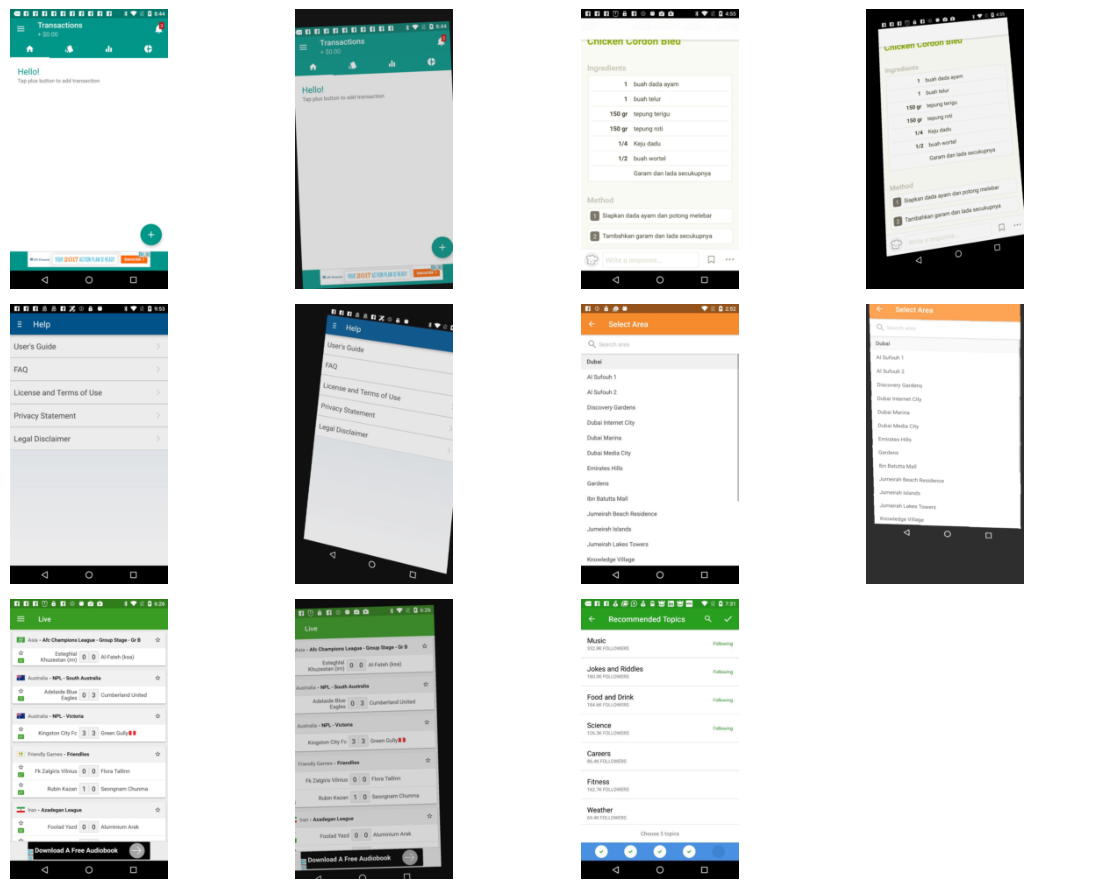

In [11]:
images = small_screen_train_dataset.get_by_label(label="list", num_samples=10)

plot_image_list(images)

**Additional functions to run the model**

In [12]:
batch_size = 128
small_screen_train_loader = torch.utils.data.DataLoader(small_screen_train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True, num_workers=3)
small_screen_val_loader = torch.utils.data.DataLoader(small_screen_val_dataset, batch_size=batch_size, shuffle=False, pin_memory=True, num_workers=3)
small_screen_test_loader = torch.utils.data.DataLoader(small_screen_test_dataset, batch_size=batch_size, shuffle=False, pin_memory=True, num_workers=3)

## Preparation of the model for fine-tuning

### 1. Training on classes with >= 70 only.

Loading the checkpoint after the initial training

In [36]:
DEVICE = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
checkpoint_path = '/kaggle/input/datasets/nazariyyuchnovskiy/20-checkpoint-batchnorm/finished_nat_images_max_epochs.pth'
model = PseudoAlexNet(p=0) # no Dropout with LeakyReLU

load_checkpoint(model=model, optimizer=None, path=checkpoint_path, device=DEVICE)

🔄 Checkpoint loaded. Status: <All keys matched successfully>
Resuming from Epoch 40 | Loss: 0.3128


(40, 0.3127840603551557)

Adapting a model to the new classification task

In [37]:
def initial_freeze_unfreeze(model):
    for param in model.parameters():
        param.requires_grad = False

    for cls_arg in model.classifier:
        for param in cls_arg.parameters():
            param.requires_grad = True
    
    for param in model.classifier[2].parameters():
        param.requires_grad = True


def second_unfreeze(model):
    for feature_arg in model.features[1:]:
        for param in feature_arg.parameters():
            param.requires_grad = True


for layer in model.classifier:
    if hasattr(layer, "reset_parameters"):
        layer.reset_parameters()
fc_last_in_features = model.classifier[-1].in_features
model.classifier[1] = nn.Linear(in_features=32*40*22, out_features=fc_last_in_features)
model.classifier[-1] = nn.Linear(in_features=fc_last_in_features, out_features=len(allowed_classes)) # exactly so much classes are in Enrico

### 2. Preparation of the parameters for fine-tuning on allowed classes

In [38]:
import torch.optim
MAX_WARMUP_EPOCHS = 5
MAX_DRIFT_EPOCHS = 10
CONFIDENCE_THRESHOLD = 1e-5
SEED = 317

model = model.to(DEVICE)

loss_fn = nn.NLLLoss()
optimizer = optim.SGD(model.parameters(), lr=1e-5, momentum=0.9)

val_loss_list_warmup_1 = []
train_loss_list_warmup_1 = []

val_loss_list_drift_1 = []
train_loss_list_drift_1 = []

### 3. Stage-1 of fine-tuning on the allowed classes

In [39]:
print("=== STAGE 1: Head Warm-up on the allowed_classes ===")

prev_loss = 0.0
print(f"Sarting training of the stage 1 in {MAX_WARMUP_EPOCHS} epochs.")
start_time = time.time()
initial_freeze_unfreeze(model=model)

for epoch in range(1, MAX_WARMUP_EPOCHS + 1):
    print(f"Warm-up Epoch {epoch}/{MAX_WARMUP_EPOCHS}...")
    
    # Run your function
    train_loss, val_loss = train_and_eval_epoch(epoch=epoch, model=model, train_loader=small_screen_train_loader,
                                                       val_loader=small_screen_val_loader,optimizer=optimizer, loss_fn=loss_fn,
                                                       device=DEVICE,log_interval=3, checkpoint_dir="/kaggle/working/",
                                                       stage_name="warmup_restricted")
    
    train_loss_list_warmup_1.append(train_loss)
    val_loss_list_warmup_1.append(val_loss)
    loss_diff = abs(prev_loss - val_loss)
    if loss_diff <= CONFIDENCE_THRESHOLD:
        print(f"\n>>> THRESHOLDS MET at Epoch {epoch} <<<")
        print(">>> Head is fully calibrated. Breaking natural images cycle.")
        save_checkpoint(model=model, optimizer=optimizer, epoch=epoch, loss=val_loss_list_warmup_1[-1], 
                        path="/kaggle/working/", file_name="finished_warmup_restricted") 
        break # Exit the warm-up loop early

    if epoch == MAX_WARMUP_EPOCHS:
        save_checkpoint(model=model, optimizer=optimizer, epoch=epoch, loss=val_loss_list_warmup_1[-1],
                        path="/kaggle/working/", file_name="finished_warmup_restricted_max_epochs")       
    prev_loss = val_loss

print(f"Finished fine-tuning on allowed-clases in {time.time() - start_time}")

=== STAGE 1: Head Warm-up on the allowed_classes ===
Sarting training of the stage 1 in 5 epochs.
Warm-up Epoch 1/5...


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c2e37fe27a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c2e37fe27a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Train Epoch: 1 [0/1408 (0%)]	Loss: 2.048184


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c2e37fe27a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process


Train Epoch: 1 [384/1408 (27%)]	Loss: 2.006524
Train Epoch: 1 [768/1408 (55%)]	Loss: 1.948450
Train Epoch: 1 [1152/1408 (82%)]	Loss: 2.017232
--- Epoch 1 Training Metrics ---
Average Train Loss: 1.980687


...


--- Epoch 4 Evaluation ---
Validation set: Average Loss: 1.940244

Total time of epoch 4 is 47.64s

Warm-up Epoch 5/5...


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c2e37fe27a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c2e37fe27a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c2e37fe27a0>    self._shutdown_workers()

Train Epoch: 5 [0/1408 (0%)]	Loss: 1.950844
Train Epoch: 5 [384/1408 (27%)]	Loss: 1.918303
Train Epoch: 5 [768/1408 (55%)]	Loss: 1.909849
Train Epoch: 5 [1152/1408 (82%)]	Loss: 1.847970
--- Epoch 5 Training Metrics ---
Average Train Loss: 1.899466


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c2e37fe27a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c2e37fe27a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16


--- Epoch 5 Evaluation ---
Validation set: Average Loss: 1.928430

Total time of epoch 5 is 44.72s

✅ Neutral Checkpoint saved to /kaggle/working/finished_warmup_restricted_max_epochs.pth
Finished fine-tuning on allowed-clases in 226.53764820098877


### 4. Stage-2 of fine-tuning on allowed classes

In [41]:
checkpoint_path = "/kaggle/working/finished_warmup_restricted_max_epochs.pth"
load_checkpoint(model=model, optimizer=None, path=checkpoint_path, device=DEVICE)
second_unfreeze(model=model)

for param_group in optimizer.param_groups:
    param_group['lr'] = 1e-5
    
print("\n=== STAGE 2: Representational Drift on the allowed classes ===")

prev_loss = 0.0
print(f"Starting training of the stage 2 in {MAX_DRIFT_EPOCHS} epochs.")
start_warmup_time = time.time()

for epoch in range(1, MAX_DRIFT_EPOCHS + 1):
    print(f"Warm-up Epoch {epoch}/{MAX_DRIFT_EPOCHS}...")
    
    # Run your function
    train_loss, val_loss = train_and_eval_epoch(epoch=epoch, model=model, train_loader=small_screen_train_loader,
                                                       val_loader=small_screen_val_loader,optimizer=optimizer, loss_fn=loss_fn,
                                                       device=DEVICE,log_interval=3, checkpoint_dir="/kaggle/working/",
                                                       stage_name="drift_restricted")
    
    train_loss_list_drift_1.append(train_loss)
    val_loss_list_drift_1.append(val_loss)
    loss_diff = abs(prev_loss - val_loss)
    if loss_diff <= CONFIDENCE_THRESHOLD:
        print(f"\n>>> THRESHOLDS MET at Epoch {epoch} <<<")
        print(">>> Head is fully calibrated. Breaking natural images cycle.")
        save_checkpoint(model=model, optimizer=optimizer, epoch=epoch, loss=val_loss_list_drift_1[-1], 
                        path="/kaggle/working/", file_name="finished_drift_restricted") 
        break # Exit the warm-up loop early

    if epoch == MAX_DRIFT_EPOCHS:
        save_checkpoint(model=model, optimizer=optimizer, epoch=epoch, loss=val_loss_list_drift_1[-1],
                        path="/kaggle/working/", file_name="finished_drift_restricted_max_epochs")       
    prev_loss = val_loss

print(f"Finished fine-tuning on allowed-clases in {time.time() - start_time}")

🔄 Checkpoint loaded. Status: <All keys matched successfully>
Resuming from Epoch 5 | Loss: 1.9284

=== STAGE 2: Representational Drift on the allowed classes ===
Starting training of the stage 2 in 10 epochs.
Warm-up Epoch 1/10...


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c2e37fe27a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c2e37fe27a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Train Epoch: 1 [0/1408 (0%)]	Loss: 1.897239
Train Epoch: 1 [384/1408 (27%)]	Loss: 1.890051
Train Epoch: 1 [768/1408 (55%)]	Loss: 1.897214
Train Epoch: 1 [1152/1408 (82%)]	Loss: 1.843820
--- Epoch 1 Training Metrics ---
Average Train Loss: 1.886398


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c2e37fe27a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c2e37fe27a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16


--- Epoch 1 Evaluation ---
Validation set: Average Loss: 1.921598

Total time of epoch 1 is 43.14s

Warm-up Epoch 2/10...


...


--- Epoch 9 Evaluation ---
Validation set: Average Loss: 1.805421

Total time of epoch 9 is 45.93s

Warm-up Epoch 10/10...


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c2e37fe27a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c2e37fe27a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Train Epoch: 10 [0/1408 (0%)]	Loss: 1.764319
Train Epoch: 10 [384/1408 (27%)]	Loss: 1.733547
Train Epoch: 10 [768/1408 (55%)]	Loss: 1.737480
Train Epoch: 10 [1152/1408 (82%)]	Loss: 1.705554
--- Epoch 10 Training Metrics ---
Average Train Loss: 1.716608


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c2e37fe27a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c2e37fe27a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16


--- Epoch 10 Evaluation ---
Validation set: Average Loss: 1.809488

✅ Neutral Checkpoint saved to /kaggle/working/after_10_drift_restricted.pth
Total time of epoch 10 is 43.50s

✅ Neutral Checkpoint saved to /kaggle/working/finished_drift_restricted_max_epochs.pth
Finished fine-tuning on allowed-clases in 717.7404005527496


**Finally showing the test result on the test set of allowed classes**

In [42]:
model.eval()
local_test_loss_sum = 0.0
local_test_steps = 0
local_test_correct = 0  
local_test_samples = 0  

device = DEVICE
with torch.no_grad():
    for data, target in small_screen_test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        loss = loss_fn(output, target)
        
        local_test_loss_sum += loss.item()
        local_test_steps += 1

        pred = output.argmax(dim=1)
        
        local_test_correct += (pred == target).sum().item()
        local_test_samples += target.size(0)

# Calculate final average loss
if local_test_steps > 0:
    avg_test_loss = local_test_loss_sum / local_test_steps
else:
    avg_test_loss = float('inf')

# Calculate final accuracy percentage
if local_test_samples > 0:
    test_accuracy = (local_test_correct / local_test_samples) * 100
else:
    test_accuracy = 0.0
    
print(f'=== Test set results after fine-tune on allowed classes ===')
print(f'Average Loss: {avg_test_loss:.6f}')
print(f'Accuracy:     {test_accuracy:.2f}%\n')

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c2e37fe27a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c2e37fe27a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

=== Test set results after fine-tune on allowed classes ===
Average Loss: 1.829991
Accuracy:     32.53%



### 5. Regenerating the train/val/test split for all classes

In [43]:
full_screen_train_dataset, full_screen_val_dataset, full_screen_test_dataset = CustomEnricoDataset.create_splits(
    root="/kaggle/input/datasets/nazariyyuchnovskiy/enrico-dataset-vanilla",
    seed=317,
    transform=universal_base,
    augment_for_each=[rare_class_aug],
    transform_to_class=augmentations,
    allowed_classes=None
)

batch_size = 128
full_screen_train_loader = torch.utils.data.DataLoader(full_screen_train_dataset, batch_size=batch_size, shuffle=False, pin_memory=True, num_workers=3)
full_screen_val_loader = torch.utils.data.DataLoader(full_screen_val_dataset, batch_size=batch_size, shuffle=False, pin_memory=True, num_workers=3)
full_screen_test_loader = torch.utils.data.DataLoader(full_screen_test_dataset, batch_size=batch_size, shuffle=False, pin_memory=True, num_workers=3)


for layer in model.classifier:
    if hasattr(layer, "reset_parameters"):
        layer.reset_parameters()
fc_last_in_features = model.classifier[-1].in_features
model.classifier[-1] = nn.Linear(in_features=fc_last_in_features, out_features=20)

### 6. Preparation of the parameters for fine-tuning

In [44]:
MAX_WARMUP_EPOCHS = 10
MAX_DRIFT_EPOCHS = 20
CONFIDENCE_THRESHOLD = 0.001
SEED = 317

loss_fn = nn.NLLLoss()
optimizer = optim.SGD(model.parameters(), lr=1e-5, momentum=0.9)

val_loss_list_warmup_2 = []
train_loss_list_warmup_2 = []

val_loss_list_drift_2 = []
train_loss_list_drift_2 = []

### 7. Stage 1 of full classes fine-tuning

In [45]:
import warnings
warnings.filterwarnings("ignore")
print("=== Phase 2: STAGE 1 Warm-up ===")

model = model.to(DEVICE)
prev_loss = 0.0
print(f"Sarting training of the stage 1 in {MAX_WARMUP_EPOCHS} epochs.")
start_warmup_time = time.time()
initial_freeze_unfreeze(model=model)

for epoch in range(1, MAX_WARMUP_EPOCHS + 1):
    print(f"Warm-up Epoch {epoch}/{MAX_WARMUP_EPOCHS}...")
    
    # Run your function
    train_loss, val_loss = train_and_eval_epoch(epoch=epoch, model=model, train_loader=full_screen_train_loader,
                                                       val_loader=full_screen_val_loader,optimizer=optimizer, loss_fn=loss_fn,
                                                       device=DEVICE,log_interval=3, checkpoint_dir="/kaggle/working/",
                                                       stage_name="warmup")
    
    train_loss_list_warmup_2.append(train_loss)
    val_loss_list_warmup_2.append(val_loss)
    loss_diff = abs(prev_loss - val_loss)
    if loss_diff <= 1e-7:
        print(f"\n>>> THRESHOLDS MET at Epoch {epoch} <<<")
        print(">>> Head is fully calibrated. Breaking natural images cycle.")
        save_checkpoint(model=model, optimizer=optimizer, epoch=epoch, loss=val_loss_list_warmup_2[-1], 
                        path="/kaggle/working/", file_name="finished_warmup") 
        break # Exit the warm-up loop early

    if epoch == MAX_WARMUP_EPOCHS:
        save_checkpoint(model=model, optimizer=optimizer, epoch=epoch, loss=val_loss_list_warmup_2[-1],
                        path="/kaggle/working/", file_name="finished_warmup_max_epochs")       
    prev_loss = val_loss

print(f"Finished fine-tuning on allowed-clases in {time.time() - start_time}")

=== Phase 2: STAGE 1 Warm-up ===
Sarting training of the stage 1 in 10 epochs.
Warm-up Epoch 1/10...


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c2e37fe27a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c2e37fe27a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Train Epoch: 1 [0/2176 (0%)]	Loss: 3.162309
Train Epoch: 1 [384/2176 (18%)]	Loss: 3.157443
Train Epoch: 1 [768/2176 (35%)]	Loss: 3.053421
Train Epoch: 1 [1152/2176 (53%)]	Loss: 3.111095
Train Epoch: 1 [1536/2176 (71%)]	Loss: 3.146087
Train Epoch: 1 [1920/2176 (88%)]	Loss: 3.152938
--- Epoch 1 Training Metrics ---
Average Train Loss: 3.137215


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c2e37fe27a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c2e37fe27a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16


--- Epoch 1 Evaluation ---
Validation set: Average Loss: 3.013100

Total time of epoch 1 is 67.35s

Warm-up Epoch 2/10...


...


--- Epoch 9 Evaluation ---
Validation set: Average Loss: 2.992983

Total time of epoch 9 is 65.29s

Warm-up Epoch 10/10...


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c2e37fe27a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c2e37fe27a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Train Epoch: 10 [0/2176 (0%)]	Loss: 2.923533
Train Epoch: 10 [384/2176 (18%)]	Loss: 2.944477
Train Epoch: 10 [768/2176 (35%)]	Loss: 2.854883
Train Epoch: 10 [1152/2176 (53%)]	Loss: 2.892834
Train Epoch: 10 [1536/2176 (71%)]	Loss: 2.918572
Train Epoch: 10 [1920/2176 (88%)]	Loss: 2.954113
--- Epoch 10 Training Metrics ---
Average Train Loss: 2.921560


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c2e37fe27a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c2e37fe27a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16


--- Epoch 10 Evaluation ---
Validation set: Average Loss: 2.974987

✅ Neutral Checkpoint saved to /kaggle/working/after_10_warmup.pth
Total time of epoch 10 is 67.28s

✅ Neutral Checkpoint saved to /kaggle/working/finished_warmup_max_epochs.pth
Finished fine-tuning on allowed-clases in 1528.1440694332123


In [51]:
import warnings
warnings.filterwarnings("ignore")
print("=== Phase 2:STAGE 2 Drift ===")

MAX_DRIFT_EPOCHS = 20
prev_loss = 0.0
print(f"Sarting training of the stage 1 in {MAX_DRIFT_EPOCHS} epochs.")
start_warmup_time = time.time()
second_unfreeze(model=model)

for epoch in range(21, MAX_DRIFT_EPOCHS + 21):
    print(f"Warm-up Epoch {epoch}/{MAX_DRIFT_EPOCHS}...")
    
    # Run your function
    train_loss, val_loss = train_and_eval_epoch(epoch=epoch, model=model, train_loader=full_screen_train_loader,
                                                       val_loader=full_screen_val_loader,optimizer=optimizer, loss_fn=loss_fn,
                                                       device=DEVICE,log_interval=3, checkpoint_dir="/kaggle/working/",
                                                       stage_name="drift")
    
    train_loss_list_warmup_2.append(train_loss)
    val_loss_list_warmup_2.append(val_loss)
    loss_diff = abs(prev_loss - val_loss)
    if loss_diff <= 1e-7:
        print(f"\n>>> THRESHOLDS MET at Epoch {epoch} <<<")
        save_checkpoint(model=model, optimizer=optimizer, epoch=epoch, loss=val_loss_list_warmup_2[-1], 
                        path="/kaggle/working/", file_name="finished_drift") 
        break # Exit the warm-up loop early

    if epoch == MAX_DRIFT_EPOCHS:
        save_checkpoint(model=model, optimizer=optimizer, epoch=epoch, loss=val_loss_list_warmup_2[-1],
                        path="/kaggle/working/", file_name="finished_drift_max_epochs")       
    prev_loss = val_loss

print(f"Finished fine-tuning  in {time.time() - start_time}")

=== Phase 2:STAGE 2 Drift ===
Sarting training of the stage 1 in 20 epochs.
Warm-up Epoch 21/20...
Train Epoch: 21 [0/2176 (0%)]	Loss: 2.547398
Train Epoch: 21 [384/2176 (18%)]	Loss: 2.626670
Train Epoch: 21 [768/2176 (35%)]	Loss: 2.492233
Train Epoch: 21 [1152/2176 (53%)]	Loss: 2.507677
Train Epoch: 21 [1536/2176 (71%)]	Loss: 2.647565
Train Epoch: 21 [1920/2176 (88%)]	Loss: 2.578118
--- Epoch 21 Training Metrics ---
Average Train Loss: 2.553741

--- Epoch 21 Evaluation ---
Validation set: Average Loss: 2.722735

Total time of epoch 21 is 66.46s

Warm-up Epoch 22/20...
Train Epoch: 22 [0/2176 (0%)]	Loss: 2.560325
Train Epoch: 22 [384/2176 (18%)]	Loss: 2.665627
Train Epoch: 22 [768/2176 (35%)]	Loss: 2.486272
Train Epoch: 22 [1152/2176 (53%)]	Loss: 2.503872
Train Epoch: 22 [1536/2176 (71%)]	Loss: 2.582241
Train Epoch: 22 [1920/2176 (88%)]	Loss: 2.634243
--- Epoch 22 Training Metrics ---
Average Train Loss: 2.551847

--- Epoch 22 Evaluation ---
Validation set: Average Loss: 2.714217

Tota

**Showing the test accuracy on the full screen dataset**

In [52]:
model.eval()
local_test_loss_sum = 0.0
local_test_steps = 0
local_test_correct = 0  
local_test_samples = 0  

device = DEVICE
with torch.no_grad():
    for data, target in full_screen_test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        loss = loss_fn(output, target)
        
        local_test_loss_sum += loss.item()
        local_test_steps += 1

        pred = output.argmax(dim=1)
        
        local_test_correct += (pred == target).sum().item()
        local_test_samples += target.size(0)

# Calculate final average loss
if local_test_steps > 0:
    avg_test_loss = local_test_loss_sum / local_test_steps
else:
    avg_test_loss = float('inf')

# Calculate final accuracy percentage
if local_test_samples > 0:
    test_accuracy = (local_test_correct / local_test_samples) * 100
else:
    test_accuracy = 0.0
    
print(f'=== Test set results after fine-tune on allowed classes ===')
print(f'Average Loss: {avg_test_loss:.6f}')
print(f'Accuracy:     {test_accuracy:.2f}%\n')

=== Test set results after fine-tune on allowed classes ===
Average Loss: 2.611382
Accuracy:     28.34%



### Plotting final train/test split

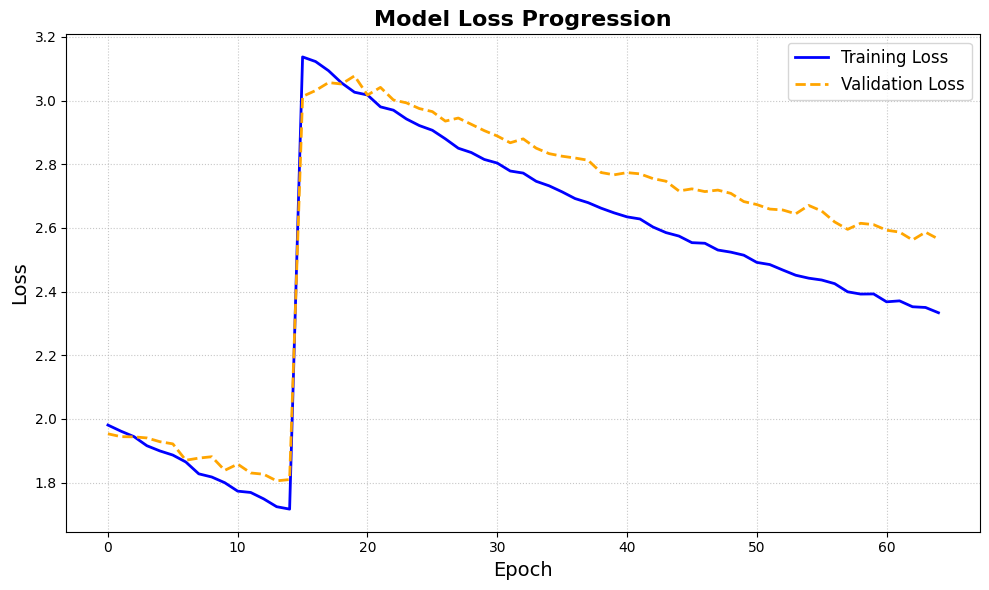

In [53]:
train_loss_list = train_loss_list_warmup_1 + train_loss_list_drift_1 + train_loss_list_warmup_2 + train_loss_list_drift_2
val_loss_list = val_loss_list_warmup_1 + val_loss_list_drift_1 + val_loss_list_warmup_2 + val_loss_list_drift_2

plot_learning_curves(train_losses=train_loss_list,val_losses=val_loss_list)

## Training the PseudoAlexNetTiny on the Enrico for comparison

In [67]:
import torch.optim
MAX_SCREEN_EPOCHS = 40
CONFIDENCE_THRESHOLD = 1e-6*2
SEED = 317

full_screen_train_dataset, full_screen_val_dataset, full_screen_test_dataset = CustomEnricoDataset.create_splits(
    root="/kaggle/input/datasets/nazariyyuchnovskiy/enrico-dataset-vanilla",
    seed=317,
    transform=universal_base,
    augment_for_each=[rare_class_aug],
    transform_to_class=augmentations,
    allowed_classes=None
)

batch_size = 128
full_screen_train_loader = torch.utils.data.DataLoader(full_screen_train_dataset, batch_size=batch_size, shuffle=False, pin_memory=True, num_workers=3)
full_screen_val_loader = torch.utils.data.DataLoader(full_screen_val_dataset, batch_size=batch_size, shuffle=False, pin_memory=True, num_workers=3)
full_screen_test_loader = torch.utils.data.DataLoader(full_screen_test_dataset, batch_size=batch_size, shuffle=False, pin_memory=True, num_workers=3)

model = PseudoAlexNet(tiny_factor=3) # with dropout and with LeakyReLU
fc_last_in_features = model.classifier[-1].in_features
model.classifier[1] = nn.Linear(in_features=10*40*22, out_features=fc_last_in_features)
model.classifier[-1] = nn.Linear(in_features=fc_last_in_features, out_features=20) # exactly so much classes are in Enrico
DEVICE = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
model = model.to(DEVICE)
    
loss_fn = nn.NLLLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-2) # adding L2 regularization

val_loss_list_screen = []
train_loss_list_screen = []

In [68]:
print("=== Training on the screen images ===")

prev_loss = 0.0
print(f"Starting training of the screen images in {MAX_SCREEN_EPOCHS} epochs.")
start_screen_time = time.time()
for epoch in range(1, MAX_SCREEN_EPOCHS + 1):
    print(f" Screen training epoch {epoch}/{MAX_SCREEN_EPOCHS}...")
    
    train_loss, val_loss = train_and_eval_epoch(epoch=epoch, model=model, train_loader=full_screen_train_loader,
                                                       val_loader=full_screen_val_loader,optimizer=optimizer, loss_fn=loss_fn,
                                                       device=DEVICE,log_interval=3, checkpoint_dir="/kaggle/working/",
                                                       stage_name="screen_images")
    
    train_loss_list_screen.append(train_loss)
    val_loss_list_screen.append(val_loss)
    loss_diff = abs(prev_loss - val_loss)
    if loss_diff <= CONFIDENCE_THRESHOLD:
        print(f"\n>>> THRESHOLDS MET at Epoch {epoch} <<<")
        print(">>> Head is fully calibrated. Breaking screeb images cycle.")
        save_checkpoint(model=model, optimizer=optimizer, epoch=epoch, loss=val_loss_list_screen[-1], 
                        path="/kaggle/working/", file_name="finished_screen_images") 
        break # Exit the training loop early

    if epoch == MAX_SCREEN_EPOCHS:
        save_checkpoint(model=model, optimizer=optimizer, epoch=epoch, loss=val_loss_list_screen[-1],
                        path="/kaggle/working/", file_name="finished_screen_images_max_epochs")       
    prev_loss = val_loss

print(f"Finished screen images training in {time.time() - start_screen_time}")

=== Training on the screen images ===
Starting training of the screen images in 40 epochs.
 Screen training epoch 1/40...
Train Epoch: 1 [0/2176 (0%)]	Loss: 3.096948
Train Epoch: 1 [384/2176 (18%)]	Loss: 2.926193
Train Epoch: 1 [768/2176 (35%)]	Loss: 2.811759
Train Epoch: 1 [1152/2176 (53%)]	Loss: 2.798870
Train Epoch: 1 [1536/2176 (71%)]	Loss: 2.373831
Train Epoch: 1 [1920/2176 (88%)]	Loss: 2.681348
--- Epoch 1 Training Metrics ---
Average Train Loss: 2.749047

--- Epoch 1 Evaluation ---
Validation set: Average Loss: 2.555162

Total time of epoch 1 is 66.36s

 Screen training epoch 2/40...
Train Epoch: 2 [0/2176 (0%)]	Loss: 2.076944
Train Epoch: 2 [384/2176 (18%)]	Loss: 2.557436
Train Epoch: 2 [768/2176 (35%)]	Loss: 2.420727
Train Epoch: 2 [1152/2176 (53%)]	Loss: 2.245106
Train Epoch: 2 [1536/2176 (71%)]	Loss: 2.222792
Train Epoch: 2 [1920/2176 (88%)]	Loss: 2.269177
--- Epoch 2 Training Metrics ---
Average Train Loss: 2.315294

--- Epoch 2 Evaluation ---
Validation set: Average Loss: 

KeyboardInterrupt: 

In [69]:
model.eval()
local_test_loss_sum = 0.0
local_test_steps = 0
local_test_correct = 0  
local_test_samples = 0  

device = DEVICE
with torch.no_grad():
    for data, target in full_screen_test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        loss = loss_fn(output, target)
        
        local_test_loss_sum += loss.item()
        local_test_steps += 1

        pred = output.argmax(dim=1)
        
        local_test_correct += (pred == target).sum().item()
        local_test_samples += target.size(0)

# Calculate final average loss
if local_test_steps > 0:
    avg_test_loss = local_test_loss_sum / local_test_steps
else:
    avg_test_loss = float('inf')

# Calculate final accuracy percentage
if local_test_samples > 0:
    test_accuracy = (local_test_correct / local_test_samples) * 100
else:
    test_accuracy = 0.0
    
print(f'=== Test set results after fine-tune on allowed classes ===')
print(f'Average Loss: {avg_test_loss:.6f}')
print(f'Accuracy:     {test_accuracy:.2f}%\n')

=== Test set results after fine-tune on allowed classes ===
Average Loss: 2.080270
Accuracy:     38.10%



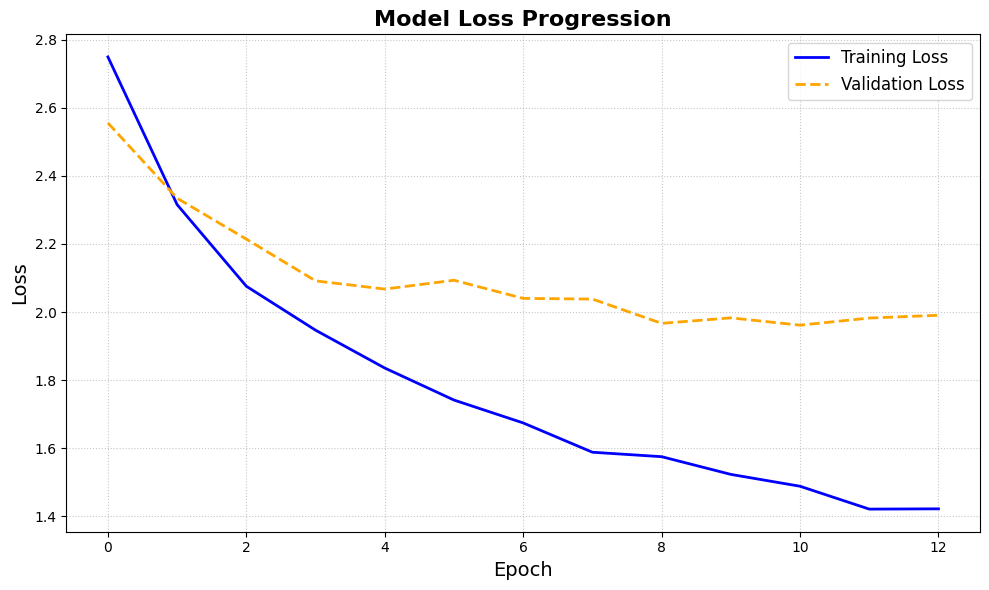

In [70]:
plot_learning_curves(train_losses=train_loss_list_screen,val_losses=val_loss_list_screen)